In [1]:
import numpy as np
import matplotlib.pyplot as plt

from markovianity_diagnostic.core import GcStar, adj_mtx, continuous_noise_fun

from tqdm.notebook import tqdm

## Simulate data

An example ground truth connectivity matrix `A`

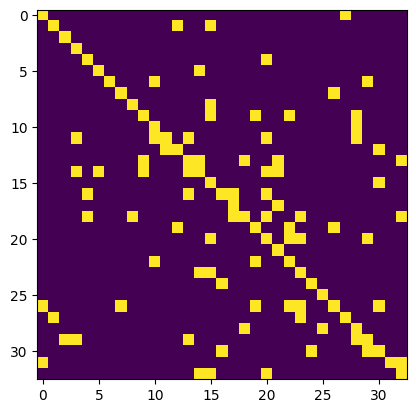

In [2]:
plt.imshow(adj_mtx(np.random.randint(25,40,1)[0])!=0)

## Analysis

In [3]:
# %%time
metrics, N_PASTS, num = [], list(range(1, 8)), 10
for a in tqdm(range(num)):
    n_neur = np.random.randint(18, 30, 1)[0]
    l = np.random.randint(5000, 10000, 1)[0]
    alpha, beta, n_lags = 0.01, 0.001, 1


    # simulate data

    A = adj_mtx(n_neur)
    noise = continuous_noise_fun(num = n_neur, l = l)
    X = np.zeros((A.shape[0], l)).T
    X[0] = np.random.randn(A.shape[0])
    for i, row in enumerate(X[:-1]):
        X[i+1] = A @ X[i] + np.random.normal(0, 0.25, A.shape[0]) + noise[:, i]
    X=X.T

    print(f'Data {a} of {num} with {X.shape[0]} vars')

    # fit algorithm to data
    met = np.zeros((len(N_PASTS), 6))
    for k, n_past in enumerate(N_PASTS):
        print(n_past)

        # intantiate the GcStar()
        gcstar = GcStar(n_perm = 1000, n_pasts = n_past, n_lags = n_lags, temporal = True)
        gcstar.fit(X, verbose=0)

        # compute metrics
        gcstar.get_connectivity_matrix(alpha=alpha, beta=beta,simulation=True)
        gcstar.compute_confusion_matrix(A, simulation=True)
        met[k] = np.round(gcstar.compute_metrics(), decimals=4)
    metrics.append(met)

  0%|          | 0/10 [00:00<?, ?it/s]

Data 0 of 10 with 18 vars
1
2
3
4
5
6
7
Data 1 of 10 with 26 vars
1
2
3
4
5
6
7
Data 2 of 10 with 18 vars
1
2
3
4
5
6
7
Data 3 of 10 with 21 vars
1
2
3
4
5
6
7
Data 4 of 10 with 27 vars
1
2
3
4
5
6
7
Data 5 of 10 with 26 vars
1
2
3
4
5
6
7
Data 6 of 10 with 21 vars
1
2
3
4
5
6
7
Data 7 of 10 with 20 vars
1
2
3
4
5
6
7
Data 8 of 10 with 28 vars
1
2
3
4
5
6
7
Data 9 of 10 with 18 vars
1
2
3
4
5
6
7


In [4]:
for met in metrics:
    print(met)

[[0.9383 0.697  1.     0.0719 0.964  0.8214]
 [0.9815 0.8846 1.     0.0216 0.9892 0.9388]
 [0.9877 0.92   1.     0.0144 0.9928 0.9583]
 [0.9938 0.9583 1.     0.0072 0.9964 0.9787]
 [0.9938 0.9583 1.     0.0072 0.9964 0.9787]
 [0.9969 1.     0.9783 0.     0.9891 0.989 ]
 [1.     1.     1.     0.     1.     1.    ]]
[[0.9541 0.9038 0.6438 0.0083 0.8178 0.752 ]
 [0.9601 0.96   0.6575 0.0033 0.8271 0.7805]
 [0.963  1.     0.6575 0.     0.8288 0.7934]
 [0.9615 1.     0.6438 0.     0.8219 0.7833]
 [0.9645 1.     0.6712 0.     0.8356 0.8033]
 [0.966  1.     0.6849 0.     0.8425 0.813 ]
 [0.9645 1.     0.6712 0.     0.8356 0.8033]]
[[0.9753 0.9487 0.8605 0.0071 0.9267 0.9024]
 [0.9691 0.9459 0.814  0.0071 0.9034 0.875 ]
 [0.9691 0.9459 0.814  0.0071 0.9034 0.875 ]
 [0.9784 1.     0.8372 0.     0.9186 0.9114]
 [0.9753 0.9487 0.8605 0.0071 0.9267 0.9024]
 [0.9722 0.9722 0.814  0.0036 0.9052 0.8861]
 [0.9691 0.9459 0.814  0.0071 0.9034 0.875 ]]
[[0.9592 0.8718 0.7234 0.0127 0.8554 0.7907]
 [0.975

In [5]:
Metrics = np.zeros((num,7,6))
for i, met in enumerate(metrics):
    Metrics[i] = met
np.mean(Metrics[:,0,0])

np.float64(0.95909)

In [6]:
np.mean(Metrics,axis=0)

array([[0.95909, 0.81853, 0.87223, 0.0297 , 0.92127, 0.8357 ],
       [0.97898, 0.94552, 0.87833, 0.00764, 0.93533, 0.90547],
       [0.98014, 0.95745, 0.87551, 0.00604, 0.93474, 0.90863],
       [0.98275, 0.97226, 0.88146, 0.00385, 0.9388 , 0.91935],
       [0.98399, 0.97791, 0.88687, 0.00314, 0.94188, 0.92564],
       [0.98368, 0.98561, 0.87642, 0.00196, 0.93723, 0.92292],
       [0.98405, 0.98293, 0.88185, 0.00236, 0.93973, 0.92515]])

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
/var/folders/my/b625dwwn62x214n4rwpf336c0000gn/T/ipykernel_40452/3683629783.py:3: SyntaxWarning: invalid escape sequence '\m'
  lab = ['$\mu_{acc}$','$\mu_{prec}$', '$\mu_{rec}$', '$\mu_{FPR}$', '$\mu_{BA}$', '$\mu_{F1}$']
/var/folders/my/b625dwwn62x214n4rwpf336c0000gn/T/ipykernel_40452/3683629783.py:3: SyntaxWarning: invalid escape sequence '\m'
  lab = ['$\mu_{acc}$','$\mu_{prec}$', '$\mu_{rec}$

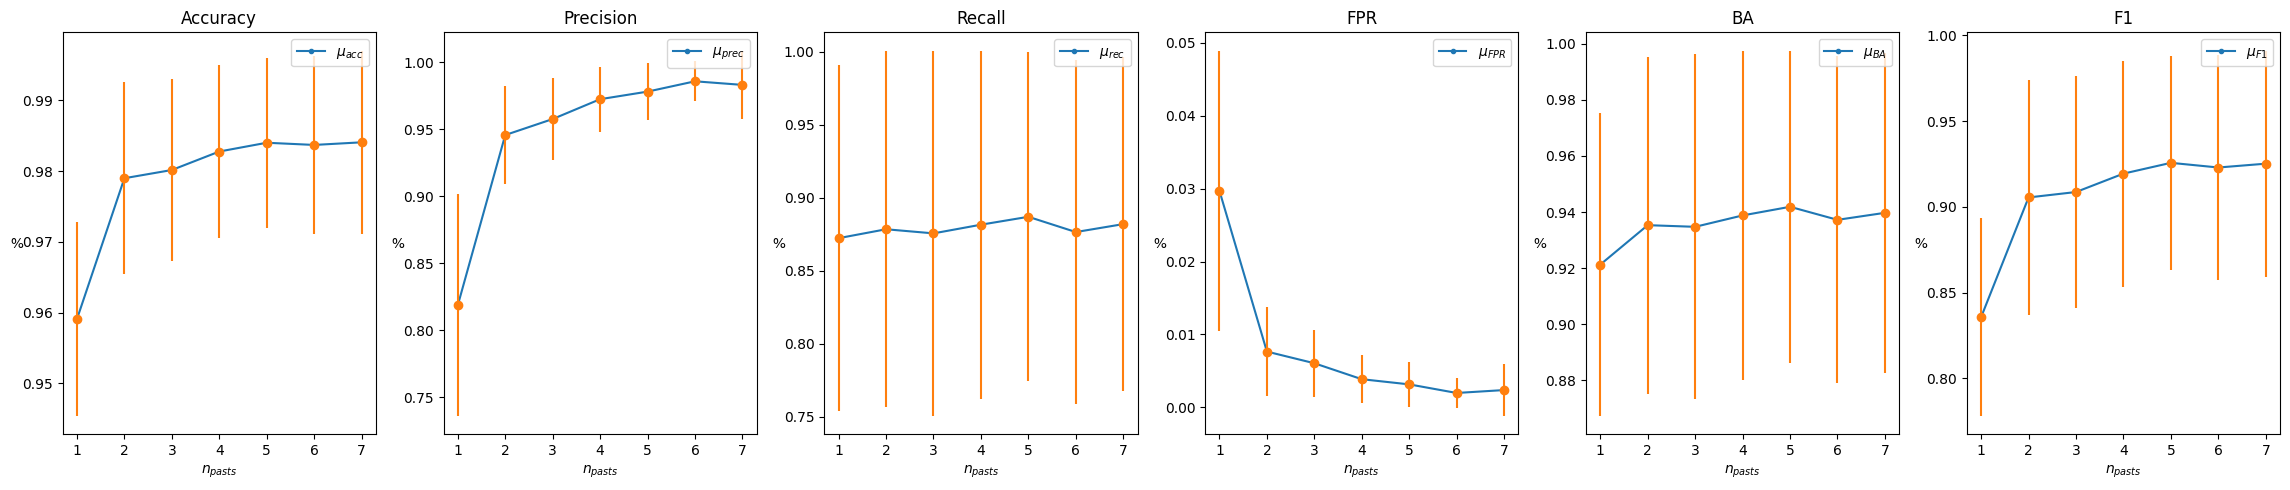

In [7]:
fig, ax = plt.subplots(1, 6, figsize = (23, 5))
labels = ['Accuracy', 'Precision', 'Recall', 'FPR', 'BA', 'F1']
lab = ['$\mu_{acc}$','$\mu_{prec}$', '$\mu_{rec}$', '$\mu_{FPR}$', '$\mu_{BA}$', '$\mu_{F1}$']
for i in range(Metrics.shape[2]):
    ax[i].plot(range(1, 1 + Metrics.shape[1]),
               np.mean(Metrics, axis = 0)[:, i],
               marker = '.', label = lab[i])
    
    ax[i].errorbar(range(1, 1 + Metrics.shape[1]),
                   np.mean(Metrics, axis = 0)[:, i],
                   yerr = np.std(Metrics, axis = 0)[:, i],
                   fmt='o')
    ax[i].set_xticks(range(1,1+Metrics.shape[1]),
                     list(range(1, 1+Metrics.shape[1])))
    ax[i].set_xlabel('$n_{pasts}$')
    ax[i].set_ylabel('%', rotation = 180)
    ax[i].set_title(f'{labels[i]}')
    ax[i].legend()
    plt.tight_layout()